This notebook contains the experiments we have and analysis on why/how they work

In [ ]:
import numpy as np
from autograd import grad
from autograd import hessian
import autograd.numpy as anp
import matplotlib.pyplot as plt
import time

This experiment is to give intuition to our problem and show that it works initially for simple problems before trying it on harder problems

#Rosenbrock = $5(y - x^2)^2 + (1 - x)^2$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la
import jax
import jax.numpy as jnp
import jax.config as config
from autograd import grad
# config.update("jax_enable_x64", True)
import numpy as np
from autograd import grad
from autograd import hessian
import autograd.numpy as anp
import matplotlib.pyplot as plt
import time

# Rosenbrock function
def rosen(x):
    return 5 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

# Use jax.grad to compute the gradient
grad_rosen = jax.grad(rosen)
hessian_rosen = jax.hessian(rosen)

In [ ]:
# @title Condition number = 133
#

# Compute the Hessian matrix of the Rosenbrock function
hessian_rosenbrock = hessian(rosen)

# Choose a point at which to evaluate the Hessian
x_point = np.array([1.0, 1.0])  # Example point (global minimum)

# Compute the Hessian matrix at the chosen point
H = hessian_rosenbrock(x_point)

# Compute the condition number of the Hessian matrix
condition_number = np.linalg.cond(H)

print("Hessian matrix at point", x_point, "is:")
print(H)
print("Condition number of the Hessian matrix is:", condition_number)


Hessian matrix at point [1. 1.] is:
[[ 42. -20.]
 [-20.  10.]]
Condition number of the Hessian matrix is: 133.19249206930226


In [ ]:
def rand_dir(grad, x, c):
  g = -grad(x)/np.linalg.norm(grad(x))
  u = np.random.rand(*(2,))
  u = u/np.linalg.norm(u)
  dir = u+(1/c)*g
  d = np.dot(g,dir)
  if d <= 0:
    rand_dir(grad, x, c)
  else:
    return dir


# @title funcs

# Gradient descent function with backtracking line search and history tracking
def gradient_descent(f, grad_f, x0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        t = 1.0  # Initial step size
        while f(x - t * gradient) > f(x) - alpha * t * np.dot(gradient, gradient):
            t *= beta
        x = x - t * gradient

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    print("grad = ", gradient)
    print("norm = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

def generate_random_descent_vector(g, c):
    dim = len(g)  # Dimension of the gradient vector
    gtemp = g / np.linalg.norm(g)
    # g /= np.linalg.norm(g)
    counter = 0
    while True:
        counter += 1
        # Generate a random unit vector 'u'
        u = np.random.uniform(-1, 1, dim)
        u /= np.linalg.norm(u)  # Normalize to make 'u' a unit vector

        # Calculate d = g ⋅ (u + 1/c * g)
        d = u + 1/c * gtemp
        check = np.dot(gtemp, d)

        # Check if the dot product is positive
        if check > 0:
            return d, counter  # Return the vector 'd'

# Gradient descent function with backtracking line search and history tracking
def random_descent(f, grad_f, x0, rand_scale = 1.0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        d, _ = generate_random_descent_vector(gradient, c = rand_scale)


        # Backtracking line Search
        t = 1.0  # Initial step size
        while f(x - t * d) > f(x) - alpha * t * np.dot(gradient, d):
            t *= beta
        x = x - t * d

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    print("grad = ", gradient)
    print("norm(grad) = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

Converged!!
grad =  [ 3.33660179e-07 -8.83571233e-07]
norm =  9.444719364344376e-07
Solution: [0.99999927 0.99999852]
Function value at solution: 5.746403053385855e-13
Number of iterations: 804
Time until convergence: 0.37778520584106445


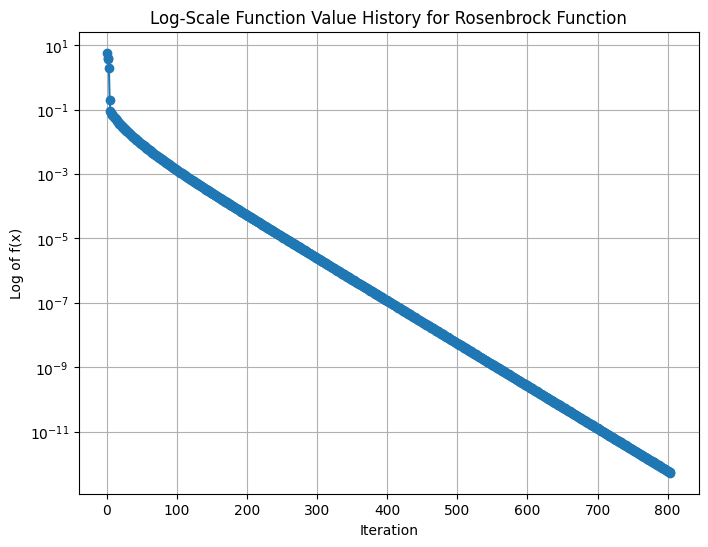

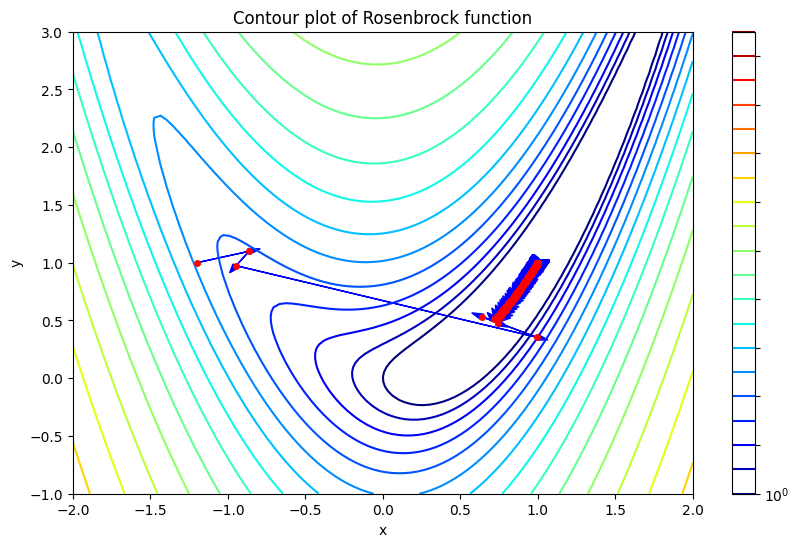

In [ ]:
# @title Grad Descnt Exp

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosen)

# Initial point for the Rosenbrock function
x0_rosenbrock = np.array([-1.2, 1.0])

# Run gradient descent
solution_rosenbrock, history2, history, iterations_rosenbrock, time_rosenbrock = gradient_descent(rosen, grad_rosenbrock_function, x0_rosenbrock)

# Print results
print("Solution:", solution_rosenbrock)
print("Function value at solution:", f_hist_rosenbrock[-1])
print("Number of iterations:", iterations_rosenbrock)
print("Time until convergence:", time_rosenbrock)

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(history2, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()


from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
# Generate the contour plot
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = rosen(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 20), norm=LogNorm(), cmap=plt.cm.jet)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour plot of Rosenbrock function')

# Plot the points chosen during iterations
for i in range(len(history)):
    # print("point: ", history[i])
    plt.plot(history[i][0], history[i][1], marker='o', color='red', markersize=4)
    if i > 0:
        plt.arrow(history[i-1][0], history[i-1][1], history[i][0] - history[i-1][0], history[i][1] - history[i-1][1], color='blue', width=0.001, head_width=0.05)

plt.show()


Converged!!
grad =  [2.62883197e-07 2.88175714e-07]
norm(grad) =  3.9006770915541064e-07
Solution: [1.00000029 1.0000007 ]
Function value at solution: 5.746403053385855e-13
Number of iterations: 91
Time until convergence: 0.07034444808959961


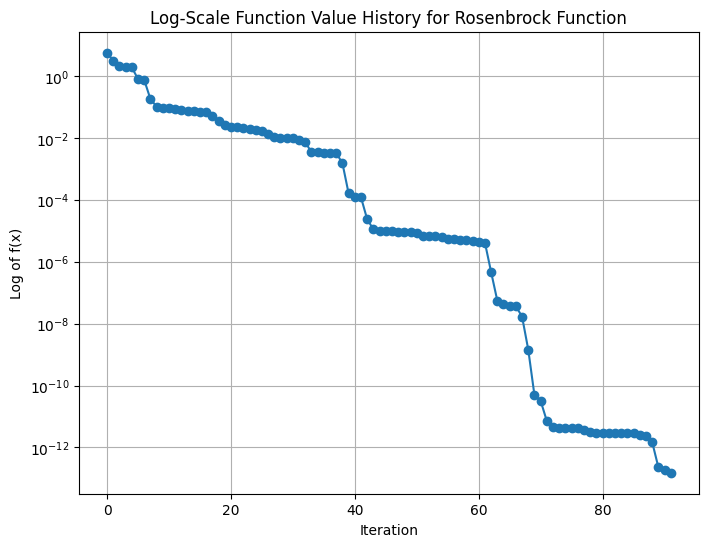

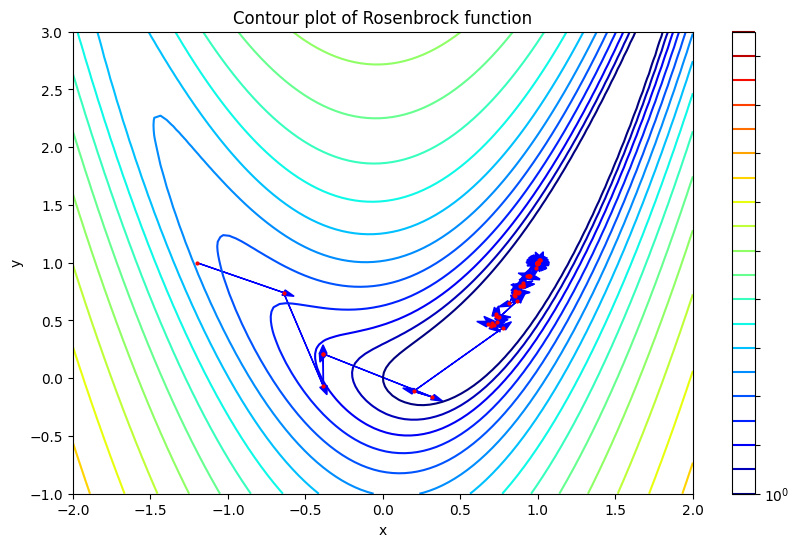

In [ ]:
# @title Rand Descnt Exp

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosen)

# Initial point for the Rosenbrock function
x0_rosenbrock = np.array([-1.2, 1.0])

# Run gradient descent
solution_rosenbrock, history2, history, iterations_rosenbrock, time_rosenbrock = random_descent(rosen, grad_rosenbrock_function, x0_rosenbrock)

# Print results
print("Solution:", solution_rosenbrock)
print("Function value at solution:", f_hist_rosenbrock[-1])
print("Number of iterations:", iterations_rosenbrock)
print("Time until convergence:", time_rosenbrock)

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(history2, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()


from matplotlib.colors import LogNorm
import matplotlib.pyplot as plt
# Generate the contour plot
x = np.linspace(-2, 2, 100)
y = np.linspace(-1, 3, 100)
X, Y = np.meshgrid(x, y)
Z = rosen(np.vstack([X.ravel(), Y.ravel()])).reshape(X.shape)

plt.figure(figsize=(10, 6))
plt.contour(X, Y, Z, levels=np.logspace(0, 3, 20), norm=LogNorm(), cmap=plt.cm.jet)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title('Contour plot of Rosenbrock function')

# Plot the points chosen during iterations
for i in range(len(history)):
    # print("point: ", history[i])
    plt.plot(history[i][0], history[i][1], marker='o', color='red', markersize=2)
    if i > 0:
        plt.arrow(history[i-1][0], history[i-1][1], history[i][0] - history[i-1][0], history[i][1] - history[i-1][1], color='blue', width=0.001, head_width=0.05)

plt.show()


# Results

Conclusion:

From this experiment, we conclude that our method indeed works (for simple problems at least).

Also, our methods seems to be performing better than vanilla gradient descent (in this problem, at least, which is slightly poorly conditioned with $\kappa = 133$).

# Rosenbrock = $1000(y - x^2)^2 + (1 - x)^2$

In [ ]:
def rosenbrock_function(x):
    """ Rosenbrock function: f(x, y) = 100(y - x^2)^2 + (1 - x)^2 """
    return 1000 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

In [ ]:
# @title funcs

# Gradient descent function with backtracking line search and history tracking
def gradient_descent(f, grad_f, x0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        t = 1.0  # Initial step size
        while f(x - t * gradient) > f(x) - alpha * t * np.dot(gradient, gradient):
            t *= beta
        x = x - t * gradient

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    print("grad = ", gradient)
    print("norm = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

def generate_random_descent_vector(g, c):
    dim = len(g)  # Dimension of the gradient vector
    gtemp = g / np.linalg.norm(g)
    # g /= np.linalg.norm(g)
    counter = 0
    while True:
        counter += 1
        # Generate a random unit vector 'u'
        u = np.random.uniform(-1, 1, dim)
        u /= np.linalg.norm(u)  # Normalize to make 'u' a unit vector

        # Calculate d = g ⋅ (u + 1/c * g)
        d = u + 1/c * gtemp
        check = np.dot(gtemp, d)

        # Check if the dot product is positive
        if check > 0:
            return d, counter  # Return the vector 'd'

# Gradient descent function with backtracking line search and history tracking
def random_descent(f, grad_f, x0, rand_scale = 1.0, alpha=0.3, beta=0.8, precision=1e-6, max_iterations=100000):
    x = x0
    x_history = [x.copy()]  # Initialize history with the starting point
    f_history = [f(x)]
    start_time = time.time()

    for iteration in range(max_iterations):
        gradient = grad_f(x)
        d, _ = generate_random_descent_vector(gradient, c = rand_scale)


        # Backtracking line Search
        t = 1.0  # Initial step size
        while f(x - t * d) > f(x) - alpha * t * np.dot(gradient, d):
            t *= beta
        x = x - t * d

        x_history.append(x.copy())  # Record the new x value
        f_history.append(f(x))
        if np.linalg.norm(gradient) < precision:
            print("Converged!!")
            break

    if (np.linalg.norm(gradient) > precision):
        print("NOT Converged!!")
    print("grad = ", gradient)
    print("norm(grad) = ", np.linalg.norm(gradient))
    time_elapsed = time.time() - start_time
    return x, f_history, np.array(x_history), iteration + 1, time_elapsed

In [ ]:
# @title Condition number = 25008
#

# Compute the Hessian matrix of the Rosenbrock function
hessian_rosenbrock = hessian(rosenbrock_function)

# Choose a point at which to evaluate the Hessian
x_point = np.array([1.0, 1.0])  # Example point (global minimum)

# Compute the Hessian matrix at the chosen point
H = hessian_rosenbrock(x_point)

# Compute the condition number of the Hessian matrix
condition_number = np.linalg.cond(H)

print("Hessian matrix at point", x_point, "is:")
print(H)
print("Condition number of the Hessian matrix is:", condition_number)


Hessian matrix at point [1. 1.] is:
[[ 8002. -4000.]
 [-4000.  2000.]]
Condition number of the Hessian matrix is: 25008.00095998314


NOT Converged!!
grad =  [-3.53606197e-05 -9.65103863e-06]
norm =  3.665400345887258e-05
Solution: [0.99997268 0.99994534]
Function value at solution: 7.4689336088544e-10
Number of iterations: 100000
Time until convergence: 87.06080746650696


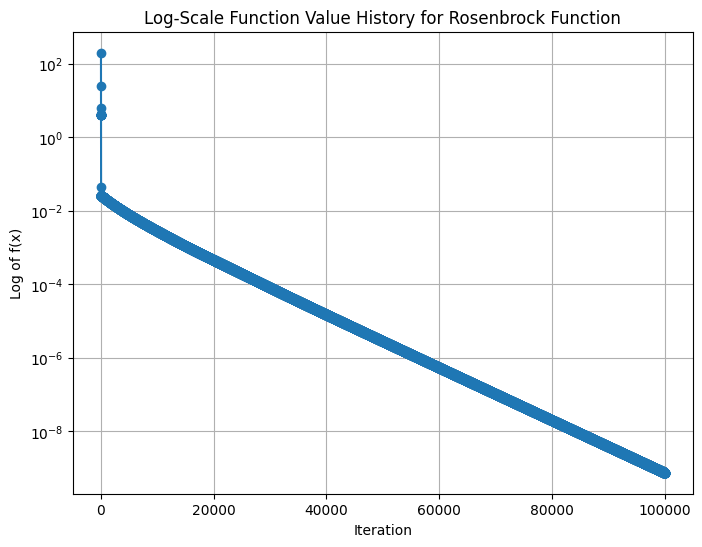

In [ ]:
# @title Grad Descnt Exp

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosenbrock_function)

# Initial point for the Rosenbrock function
x0_rosenbrock = np.array([-1.2, 1.0])

# Run gradient descent
solution_rosenbrock, f_hist_rosenbrock, x_hist_grad_descent, iterations_rosenbrock, time_rosenbrock = gradient_descent(rosenbrock_function, grad_rosenbrock_function, x0_rosenbrock)

# Print results
print("Solution:", solution_rosenbrock)
print("Function value at solution:", f_hist_rosenbrock[-1])
print("Number of iterations:", iterations_rosenbrock)
print("Time until convergence:", time_rosenbrock)

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()


Converged!!
grad =  [1.95009824e-07 2.07880824e-07]
norm(grad) =  2.850320477775845e-07
Solution: [1.00000031 1.00000061]
Function value at solution: 9.326236018329917e-14
Number of iterations: 748
Time until convergence: 0.6232655048370361


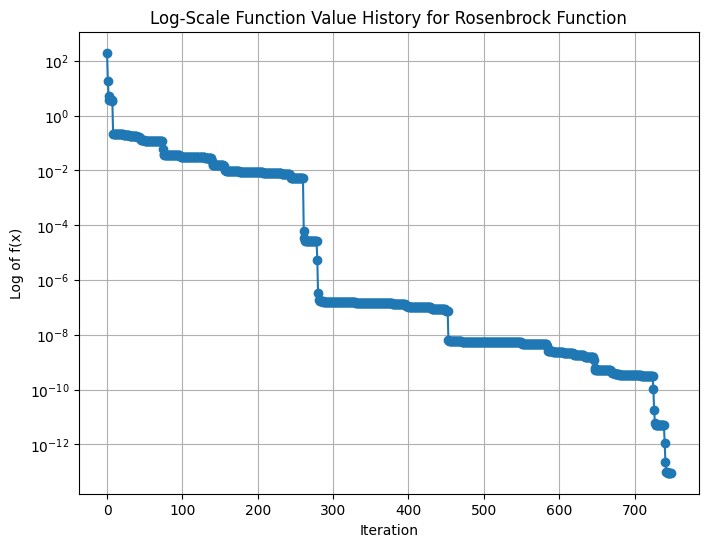

In [ ]:
# @title Rand Descent Exp

# Rosenbrock Function: f_rosenbrock(x) = 100(y - x^2)^2 + (1 - x)^2
def rosenbrock_function(x):
    return 1000 * (x[1] - x[0]**2)**2 + (1 - x[0])**2

# Automatic gradient computation using Autograd
grad_rosenbrock_function = grad(rosenbrock_function)

# Initial point for the Rosenbrock function
x0_rosenbrock = np.array([-1.2, 1.0])

# Run gradient descent
solution_rosenbrock_rand, f_hist_rosenbrock_rand, x_hist_rosenbrock_rand, iterations_rosenbrock_rand, time_rosenbrock_rand = random_descent(rosenbrock_function, grad_rosenbrock_function, x0_rosenbrock, rand_scale= 1)

# Print results
print("Solution:", solution_rosenbrock_rand)
print("Function value at solution:", f_hist_rosenbrock_rand[-1])
print("Number of iterations:", iterations_rosenbrock_rand)
print("Time until convergence:", time_rosenbrock_rand)

# Plotting the function value history on a log-scale
plt.figure(figsize=(8, 6))
plt.plot(f_hist_rosenbrock_rand, marker='o', linestyle='-')
plt.yscale('log')
plt.title('Log-Scale Function Value History for Rosenbrock Function')
plt.xlabel('Iteration')
plt.ylabel('Log of f(x)')
plt.grid(True)
plt.show()


# Minimal Surface Problem
$ f(\mathbf{x}) = 2\pi h x_1 \sqrt{1 + \left(\frac{x_1 - r_0}{h}\right)^2} + 2\pi h \sum_{i=1}^{n-1} x_i \sqrt{1 + \left(\frac{x_{i+1} - x_i}{h}\right)^2} + 2\pi h x_n \sqrt{1 + \left(\frac{r_0 - x_n}{h}\right)^2}
 $

Minimal Surface. Consider the problem of generating a shape with minimal surface area. The shape is a surface of revolution about a vertical axis of length l (see figure below). Because of circular symmetry, the problem reduces to finding the radii of horizontal cross sections. The radii of the cross sections are fixed on the top and bottom at r0. We can discretize the problem so the unknowns x represent the radii at n locations equally spaced along the vertical axis at a distance h = l/(n + 1). With this discretization the surface area may be approximated by the following function: